<a href="https://colab.research.google.com/github/homiecal/dap-playground/blob/master/CLIP_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Testing weak-artefact augmentations on Chefer interpretabililty method**

[4] introduces a method Disease Aware Prompting for weakly-supervised medical visual grounding. Given the vulnerability of VLMs to noise and imaging artefacts [3] I thought it would be interesting to investigate the robustness of DAP to weak-artefacts introduced at the image level (in pixel-space).

[4] already provides substantial evidence that DAP remains useful when the underlying visual grounding using [1] is imperfect. For example, Appendix E analyses robustness to a flawed Φ, while Fig. 14 in Appendix A shows that DAP continues to outperform the baselines even when Φ performs poorly (Dice < 0.3). Chefer et al. [1] also includes ablation experiments investigating the effect of perturbations on the interpretability approach, although their ablations operate at the token level rather than directly perturbing the image.

This notebook includes a qualitative exploration of the effect of weak-artefacts on Φ, informing us on the potential downstream implications for DAP.

[1] Chefer, Hila, Shir Gur, and Lior Wolf. “Generic Attention-Model Explainability for Interpreting Bi-Modal and Encoder-Decoder Transformers.” arXiv:2103.15679. Preprint, arXiv, March 29, 2021. [https://doi.org/10.48550/arXiv.2103.15679](https://doi.org/10.48550/arXiv.2103.15679).

[2] Tiu, Ekin, Ellie Talius, Pujan Patel, Curtis P. Langlotz, Andrew Y. Ng, and Pranav Rajpurkar. “Expert-Level Detection of Pathologies from Unannotated Chest X-Ray Images via Self-Supervised Learning.” _Nature Biomedical Engineering_ 6, no. 12 (2022): 1399–406. [https://doi.org/10.1038/s41551-022-00936-9](https://doi.org/10.1038/s41551-022-00936-9).

[3] Cheng, Zijie, Ariel Yuhan Ong, Siegfried K. Wagner, et al. “Understanding the Robustness of Vision-Language Models to Medical Image Artefacts.” _NPJ Digital Medicine_ 8 (November 2025): 727. [https://doi.org/10.1038/s41746-025-02108-w](https://doi.org/10.1038/s41746-025-02108-w).

[4] Huy, Ta Duc, Duy Anh Huynh, Yutong Xie, et al. “Seeing the Trees for the Forest: Rethinking Weakly-Supervised Medical Visual Grounding.” arXiv:2505.15123. Preprint, arXiv, August 24, 2025. [https://doi.org/10.48550/arXiv.2505.15123](https://doi.org/10.48550/arXiv.2505.15123).


In [ ]:
!git clone https://github.com/hila-chefer/Transformer-MM-Explainability

# import os
# os.chdir(f'./Transformer-MM-Explainability')

!pip install -q einops ftfy captum

fatal: destination path 'Transformer-MM-Explainability' already exists and is not an empty directory.


# **CLIP** (CheXzero)

Load the CLIP architecture from Chefer [8] library (Transformer-MM-Explainability), then load the ChexZero model weights.

The ChexZero model checkpoint weights can be downloaded from [here](https://drive.google.com/drive/folders/1makFLiEMbSleYltaRxw81aBhEDMpVwno?usp=sharing) otherwise revisit the [README.md](https://github.com/rajpurkarlab/CheXzero/tree/main) from the repository.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/rajpurkarlab/CheXzero.git

fatal: destination path 'CheXzero' already exists and is not an empty directory.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Ignore non-issue warnings with builds for CheXzero
!pip install -q -r CheXzero/requirements.txt

  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  error: subprocess-exited-with-error
  
  × pip subprocess to install backend dependencies did not run successfully.
  │ exit code: 2
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing backend dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install backend dependencies did not run successfully.
│ exit code: 2
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
!pip -q install h5py torchio

In [ ]:
import os
os.getcwd()

'/content'

In [ ]:
# Import Chefer CLIP function to ensure underlying CLIP structure captures the forward pass attention, and backward pass gradients
import sys

sys.path.insert(0, "/content/Transformer-MM-Explainability")

import CLIP.clip as clip
from CLIP.clip.model import CLIP

print(clip.__file__)

/content/Transformer-MM-Explainability/CLIP/clip/__init__.py


In [ ]:
import torch
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from captum.attr import visualization

### Load ChezXero weights into CLIP

In [ ]:
MODEL_CHECKPOINT = "/content/drive/MyDrive/Research/model-weights/chexzero/best_64_0.0001_original_35000_0.864.pt"

In [ ]:
import sys
def load_clip(model_path, pretrained=False, context_length=77):
    """
    FUNCTION: load_clip
    ---------------------------------
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if pretrained is False:
        # use new model params
        params = {
            'embed_dim':512,
            'image_resolution': 224,
            'vision_layers': 12,
            'vision_width': 768,
            'vision_patch_size': 32,
            'context_length': context_length,
            'vocab_size': 49408,
            'transformer_width': 512,
            'transformer_heads': 8,
            'transformer_layers': 12
        }

        model = CLIP(**params)
    else:
        model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
    except:
        print("Argument error. Set pretrained = True.", sys.exc_info()[0])
        raise
    return model


In [ ]:
model = load_clip(MODEL_CHECKPOINT, False)

## Intepretability Chefer et. al and Visualisation functions

Copied and adapted from [CLIP-explainability.ipynb](https://github.com/hila-chefer/Transformer-MM-Explainability/blob/main/CLIP_explainability.ipynb).

In [ ]:
#@title Control context expansion (number of attention layers to consider)
#@title Number of layers for image Transformer
start_layer =  -1#@param {type:"number"}

#@title Number of layers for text Transformer
start_layer_text =  -1#@param {type:"number"}

In [ ]:
def interpret(image, texts, model, device, start_layer=start_layer, start_layer_text=start_layer_text):
    batch_size = texts.shape[0]
    images = image.repeat(batch_size, 1, 1, 1)
    logits_per_image, logits_per_text = model(images, texts)
    probs = logits_per_image.softmax(dim=-1).detach().cpu().numpy()
    index = [i for i in range(batch_size)]
    one_hot = np.zeros((logits_per_image.shape[0], logits_per_image.shape[1]), dtype=np.float32)
    one_hot[torch.arange(logits_per_image.shape[0]), index] = 1
    one_hot = torch.from_numpy(one_hot).requires_grad_(True)
    one_hot = torch.sum(one_hot.cuda() * logits_per_image)
    model.zero_grad()

    image_attn_blocks = list(dict(model.visual.transformer.resblocks.named_children()).values())

    if start_layer == -1:
      # calculate index of last layer
      start_layer = len(image_attn_blocks) - 1

    num_tokens = image_attn_blocks[0].attn_probs.shape[-1]
    R = torch.eye(num_tokens, num_tokens, dtype=image_attn_blocks[0].attn_probs.dtype).to(device)
    R = R.unsqueeze(0).expand(batch_size, num_tokens, num_tokens)
    for i, blk in enumerate(image_attn_blocks):
        if i < start_layer:
          continue
        grad = torch.autograd.grad(one_hot, [blk.attn_probs], retain_graph=True)[0].detach()
        cam = blk.attn_probs.detach()
        cam = cam.reshape(-1, cam.shape[-1], cam.shape[-1])
        grad = grad.reshape(-1, grad.shape[-1], grad.shape[-1])
        cam = grad * cam
        cam = cam.reshape(batch_size, -1, cam.shape[-1], cam.shape[-1])
        cam = cam.clamp(min=0).mean(dim=1)
        R = R + torch.bmm(cam, R)
    image_relevance = R[:, 0, 1:]


    text_attn_blocks = list(dict(model.transformer.resblocks.named_children()).values())

    if start_layer_text == -1:
      # calculate index of last layer
      start_layer_text = len(text_attn_blocks) - 1

    num_tokens = text_attn_blocks[0].attn_probs.shape[-1]
    R_text = torch.eye(num_tokens, num_tokens, dtype=text_attn_blocks[0].attn_probs.dtype).to(device)
    R_text = R_text.unsqueeze(0).expand(batch_size, num_tokens, num_tokens)
    for i, blk in enumerate(text_attn_blocks):
        if i < start_layer_text:
          continue
        grad = torch.autograd.grad(one_hot, [blk.attn_probs], retain_graph=True)[0].detach()
        cam = blk.attn_probs.detach()
        cam = cam.reshape(-1, cam.shape[-1], cam.shape[-1])
        grad = grad.reshape(-1, grad.shape[-1], grad.shape[-1])
        cam = grad * cam
        cam = cam.reshape(batch_size, -1, cam.shape[-1], cam.shape[-1])
        cam = cam.clamp(min=0).mean(dim=1)
        R_text = R_text + torch.bmm(cam, R_text)
    text_relevance = R_text

    return text_relevance, image_relevance

In [ ]:
def show_image_relevance(image_relevance, image, orig_image, bboxes=None):
    # create heatmap from mask on image
    def show_cam_on_image(img, mask):
        heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
        heatmap = np.float32(heatmap) / 255
        cam = heatmap + np.float32(img)
        cam = cam / np.max(cam)
        return cam

    num_subplots = 2 if bboxes is None else 3
    fig, axs = plt.subplots(1, num_subplots)
    axs[0].imshow(orig_image);
    axs[0].axis('off');
    axs[1].set_title("Original Image")


    dim = int(image_relevance.numel() ** 0.5)
    image_relevance = image_relevance.reshape(1, 1, dim, dim)
    image_relevance = torch.nn.functional.interpolate(image_relevance, size=224, mode='bilinear')
    image_relevance = image_relevance.reshape(224, 224).cuda().data.cpu().numpy()
    image_relevance = (image_relevance - image_relevance.min()) / (image_relevance.max() - image_relevance.min())
    image = image[0].permute(1, 2, 0).data.cpu().numpy()
    image = (image - image.min()) / (image.max() - image.min())
    vis = show_cam_on_image(image, image_relevance)
    vis = np.uint8(255 * vis)
    vis = cv2.cvtColor(np.array(vis), cv2.COLOR_RGB2BGR)
    axs[1].imshow(vis);
    axs[1].axis('off');
    axs[1].set_title("Interpretability Map")

      # Draw GT boxes on original image
    if bboxes is not None:
        axs[2].imshow(orig_image)
        axs[2].axis('off')
        axs[2].set_title("Ground Truth")
        orig_w, orig_h = orig_image.size

        for bbox in bboxes:
            x1, y1, x2, y2 = bbox

            # Normalised coordinates -> original image pixels
            x1 *= orig_w
            x2 *= orig_w
            y1 *= orig_h
            y2 *= orig_h

            rect = plt.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2
            )
            axs[2].imshow(orig_image);
            axs[2].add_patch(rect)

In [ ]:
from CLIP.clip.simple_tokenizer import SimpleTokenizer as _Tokenizer
_tokenizer = _Tokenizer()

def show_heatmap_on_text(text, text_encoding, R_text):
  CLS_idx = text_encoding.argmax(dim=-1)
  R_text = R_text[CLS_idx, 1:CLS_idx]
  text_scores = R_text / R_text.sum()
  text_scores = text_scores.flatten()
  print(text_scores)
  text_tokens=_tokenizer.encode(text)
  text_tokens_decoded=[_tokenizer.decode([a]) for a in text_tokens]
  vis_data_records = [visualization.VisualizationDataRecord(text_scores,0,0,0,0,0,text_tokens_decoded,1)]
  visualization.visualize_text(vis_data_records)

## Transform and Visualisation functions


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:

class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [ ]:
from torchvision.transforms import Compose, Normalize, Resize, InterpolationMode, ToTensor

padchest_transforms = Compose([
    ToTensor(),
    lambda x: x.float() / 65535 * 255,
    lambda x: x.repeat(3, 1, 1),
    Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
    Normalize(
        (101.48761,) * 3,
        (83.43944,) * 3
    ),
])

In [ ]:
import torchio as tio
def padchest_transforms_w_noise(original_image):
  original_array = np.array(original_image, dtype=np.float32)

  # 16-bit [0, 65535] → [0, 1]
  image = torch.from_numpy(original_array) / 65535.0

  # Add noise in the [0, 1] intensity space
  noise = tio.RandomNoise(mean=0, std=0.15)
  image = noise(image.unsqueeze(0).unsqueeze(0))
  image = image.squeeze(0).squeeze(0)

  # Convert to the intensity scale expected by your CheXzero preprocessing
  image = image * 255

  # Make RGB
  image = image.unsqueeze(0).repeat(3, 1, 1)

  # Resize
  image = Resize(
      (224, 224),
      interpolation=InterpolationMode.BICUBIC
  )(image)

  # CheXzero normalization
  image = Normalize(
      (101.48761,) * 3,
      (83.43944,) * 3
  )(image)

  return image

In [ ]:
def get_texts_and_bboxes(image_id, gt_by_image):
  gt_report = gt_by_image[image_id]

  texts = []
  bboxes = []
  for i in gt_report["findings"]:
    texts.append(i['sentence_en'])

    if 'boxes' in i.keys():
      bboxes.append(tuple(box for box in i['boxes']))
    else:
      bboxes.append([])
  return texts, bboxes

In [ ]:
def get_interpret(image_relevance):
    dim = int(image_relevance.numel() ** 0.5)
    image_relevance = image_relevance.reshape(1, 1, dim, dim)
    image_relevance = torch.nn.functional.interpolate(image_relevance, size=224, mode='bilinear')
    image_relevance = image_relevance.reshape(224, 224).cuda().data.cpu()
    image_relevance = (image_relevance - image_relevance.min()) / (image_relevance.max() - image_relevance.min())
    return image_relevance

In [ ]:
def dice_score(image_relevance, bboxes, thresholds):

  image_relevance = get_interpret(image_relevance)

  scores = {"thresholds":thresholds, "dice":[]}
  for i in thresholds:
    pred = image_relevance > i

    gt_mask = torch.zeros((224, 224), dtype=torch.bool)
    for bbox in bboxes:
      x1, y1, x2, y2 = bbox
      resize_h, resize_w = image_relevance.shape[-2:]
      x1 = round(x1 * resize_w)
      x2 = round(x2 * resize_w)
      y1 = round(y1 * resize_h)
      y2 = round(y2 * resize_h)
      gt_mask[y1:y2, x1:x2] = True

    intersection = (gt_mask & pred).sum()
    dice = (2*intersection / (gt_mask.sum() + pred.sum())).item()
    scores['dice'].append(dice)
  return scores

## PadChest-GR Interpretability Visualisation Example

You can download PadChest-GR dataset from https://bimcv.cipf.es/bimcv-projects/padchest/

Here I take a random chest x-ray from PadChest-GR, compute the interpretability map Φ [1] using the disease text directly (sentence_en) from the radiology findings and calculate the Dice Score against different thresholds (0.3, 0.4, 0.5), for the original image and the image with weak-artefact noise [3].

For this example "10450943868122049402445170229611131573_2t4f3c.png" the Φ shows a substantial reduction in Dice with the GT masks:

| Threshold for Φ | Dice (original image) | Dice (noisey image) | Absolute drop | Relative decrease |
| --------- | ------------: | ---------: | ------------: | ----------------: |
| 0.3       |         0.301 |      0.052 |     **0.249** |         **82.6%** |
| 0.4       |         0.248 |      0.019 |     **0.229** |         **92.3%** |
| 0.5       |         0.225 |      0.003 |     **0.222** |         **98.5%** |


In [ ]:
import json
GROUNDED_REPORTS = "/content/drive/MyDrive/Research/data/padchest-gr/grounded_reports_20240819.json"
with open(
   GROUNDED_REPORTS,
    encoding="utf-8",
) as f:
    gt_by_image = {record["ImageID"]: record for record in json.load(f)}


tensor([0.1966, 0.0101, 0.7933], device='cuda:0')


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,0 (0.00),0,0.00,air tra pping


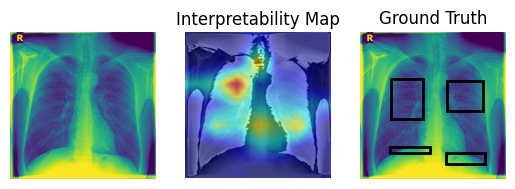

{'thresholds': [0.3, 0.4, 0.5], 'dice': [0.30072394013404846, 0.24790936708450317, 0.22510075569152832]}


In [ ]:
# Image from padchest
image_id = "10450943868122049402445170229611131573_2t4f3c.png"
img_path = f"/content/drive/MyDrive/Research/data/padchest-gr/PadChest_GR/{image_id}"
img = padchest_transforms(Image.open(img_path))
# CheXzero transforms
img = img.unsqueeze(0).to(device)

texts, bboxes = get_texts_and_bboxes(image_id, gt_by_image)

# texts = ["Cardiomegaly", "Bilateral costophrenic angle blunting suggesting pleural effusions.", "Prominent hila, likely vascular.", "New right upper lobe alveolar infiltrate, possibly cardiogenic or inflammatory/infectious."]
# texts = ["air trapping"]
text = clip.tokenize(texts).to(device)

thresholds = [0.3,0.4,0.5]

# Move the model to the GPU if it's not already there
model = model.to(device)

R_text, R_image = interpret(model=model, image=img, texts=text, device=device)
batch_size = text.shape[0]
dice_results = []
for i in range(batch_size):
  show_heatmap_on_text(texts[i], text[i], R_text[i])
  show_image_relevance(R_image[i], img, orig_image=Image.open(img_path), bboxes=bboxes[i])
  plt.show()
  dice_results.append(dice_score(R_image[i], bboxes[i], thresholds))

print(dice_results)

tensor([0.0439, 0.0206, 0.9356], device='cuda:0')


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,0 (0.00),0,0.00,air tra pping


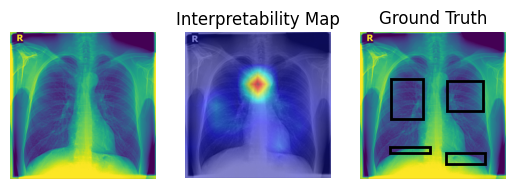

{'thresholds': [0.3, 0.4, 0.5], 'dice': [0.05216612666845322, 0.018988102674484253, 0.003302845638245344]}


In [ ]:
# Image from padchest
image_id = "10450943868122049402445170229611131573_2t4f3c.png"
img_path = f"/content/drive/MyDrive/Research/data/padchest-gr/PadChest_GR/{image_id}"
img = padchest_transforms_w_noise(Image.open(img_path))
# CheXzero transforms
img = img.unsqueeze(0).to(device)

texts, bboxes = get_texts_and_bboxes(image_id, gt_by_image)

# texts = ["Cardiomegaly", "Bilateral costophrenic angle blunting suggesting pleural effusions.", "Prominent hila, likely vascular.", "New right upper lobe alveolar infiltrate, possibly cardiogenic or inflammatory/infectious."]
texts = ["air trapping"]
text = clip.tokenize(texts).to(device)

thresholds = [0.3,0.4,0.5]

# Move the model to the GPU if it's not already there
model = model.to(device)

R_text, R_image = interpret(model=model, image=img, texts=text, device=device)
batch_size = text.shape[0]
dice_results_noise = []
for i in range(batch_size):
  show_heatmap_on_text(texts[i], text[i], R_text[i])
  show_image_relevance(R_image[i], img, orig_image=Image.open(img_path), bboxes=bboxes[i])
  plt.show()
  dice_results_noise.append(dice_score(R_image[i], bboxes[i], thresholds))

print(dice_results_noise)

# Qualitative investigation of augmentations on Chefer interpretability

Weak-artefact intensity augmentation (Biasfield, Noise, Motion) were used from this paper [3]. These are qualitative results only - we only produce results per image. To investigate the statistical significance and make a quantative judgement on the effect of weak-artefacts on Chefer [2] then we would assess the affect across multiple different datasets with a much larger sample size.

One thing to note here aswell, is that given noise artefacts are introduced at the pixel image space level, and not the feature level - our conclusion is not that Chefer intrepretability is insufficient/sufficient, but instead it will inform us on VLMs current capabilities for visual grounding for medical disease tasks with weak-artefacts at the image level (for the specific VLM and datasets tested). Given the improvement DAP [4] makes on the Chefer interpretability map even when the map has a low dice with ground truth masks, it would be interesting to see how DAP would perform when the image has weak-arefacts and whether exploring and developing methods for robustly handling weak-artefacts is a tractable problem.

In [2]:
import random
import glob

files = glob.glob("/content/drive/MyDrive/Research/data/padchest-gr/PadChest_GR/*")

n_images = 10
indexes = random.sample(range(len(files)),n_images)
sampled_images = [files[i] for i in indexes]

tensor([0.0089, 0.0362, 0.3173, 0.3947, 0.2429], device='cuda:0')


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,0 (0.00),0,0.00,a man with eye glasses


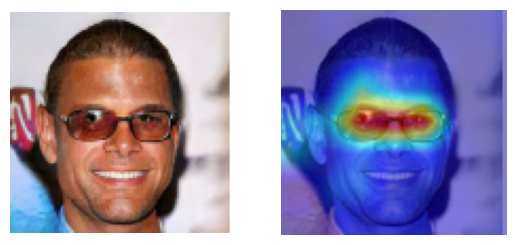

In [ ]:

for img_path in sampled_images:
  img_path = f"/content/drive/MyDrive/Research/data/padchest-gr/PadChest_GR/{image_id}"
  img = padchest_transforms(Image.open(img_path))
  # CheXzero transforms
  img = img.unsqueeze(0).to(device)

  texts, bboxes = get_texts_and_bboxes(image_id, gt_by_image)

  text = clip.tokenize(texts).to(device)

  # Move the model to the GPU if it's not already there
  model = model.to(device)

  R_text, R_image = interpret(model=model, image=img, texts=text, device=device)
  R_text, R_image_noise =
  batch_size = text.shape[0]
  dice_results_noise = []
  for i in range(batch_size):
    show_heatmap_on_text(texts[i], text[i], R_text[i])
    show_image_relevance(R_image[i], img, orig_image=Image.open(img_path), bboxes=bboxes[i])
    plt.show()
    dice_results_noise.append(dice_score(R_image[i], bboxes[i], thresholds))

  print(dice_results_noise)